Lab 27.2 – Activation Functions
Goal:

Implement sigmoid, tanh, ReLU (plus optional LeakyReLU / Softplus)

Plot activations & derivatives side‑by‑side

Compare saturation, gradient flow, and output ranges

In [1]:
# pip install numpy matplotlib
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

In [2]:
def sigmoid(x):
    # numerically stable
    out = np.empty_like(x, dtype=float)
    pos = x >= 0
    neg = ~pos
    out[pos] = 1.0 / (1.0 + np.exp(-x[pos]))
    expx = np.exp(x[neg])
    out[neg] = expx / (1.0 + expx)
    return out
 
def d_sigmoid(x):
    s = sigmoid(x)
    return s * (s - 1.0) * -1.0  # s*(1-s)
 
def tanh(x):
    return np.tanh(x)
 
def d_tanh(x):
    t = np.tanh(x)
    return 1.0 - t**2
 
def relu(x):
    return np.maximum(0.0, x)
 
def d_relu(x):
    return (x > 0).astype(float)
 
# Optional extras
def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)
 
def d_leaky_relu(x, alpha=0.01):
    out = np.ones_like(x, dtype=float)
    out[x < 0] = alpha
    out[x == 0] = alpha  # convention
    return out
 
def softplus(x):  # smooth ReLU
    # stable log(1+exp(x))
    out = np.empty_like(x, dtype=float)
    pos = x > 0
    out[pos] = x[pos] + np.log1p(np.exp(-x[pos]))
    out[~pos] = np.log1p(np.exp(x[~pos]))
    return out
 
def d_softplus(x):
    return sigmoid(x)

Plot activations on a common domain

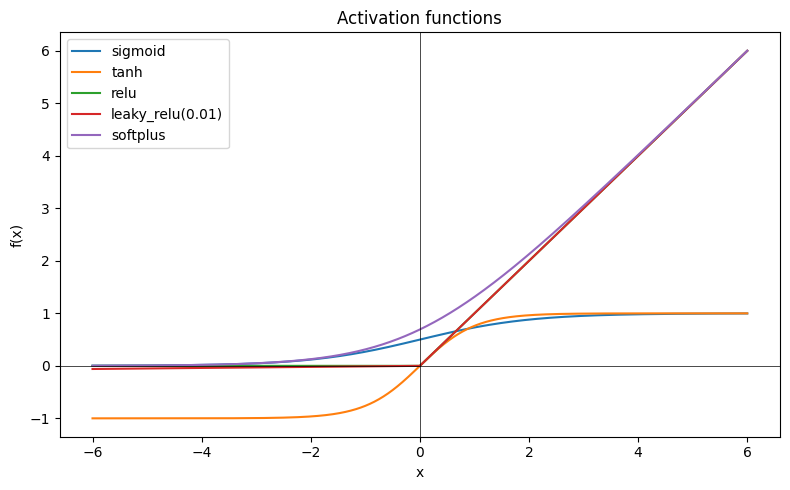

In [3]:
xs = np.linspace(-6, 6, 1000)
acts = {
    "sigmoid": sigmoid(xs),
    "tanh": tanh(xs),
    "relu": relu(xs),
    "leaky_relu(0.01)": leaky_relu(xs),
    "softplus": softplus(xs)
}
 
plt.figure(figsize=(8,5))
for name, y in acts.items():
    plt.plot(xs, y, label=name)
plt.axhline(0, color='k', lw=0.5); plt.axvline(0, color='k', lw=0.5)
plt.title("Activation functions")
plt.legend()
plt.xlabel("x"); plt.ylabel("f(x)")
plt.tight_layout(); plt.show()

What you should notice

Sigmoid outputs in (0,1), saturates for |x|≫0 → tiny gradients near 0 or 1.

Tanh outputs in (−1,1), zero‑centered (often nicer than sigmoid).

ReLU is 0 for x<0 and linear for x>0 (no saturation on positive side, sparse activation).

LeakyReLU fixes ReLU’s dead‑neuron issue (non‑zero slope for x<0).

Softplus is a smooth ReLU.

Plot derivatives (gradient flow!)

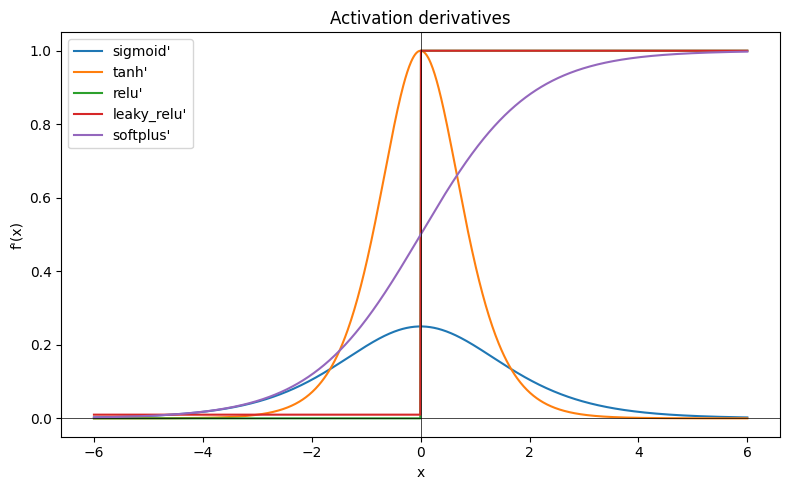

In [4]:
ders = {
    "sigmoid'": d_sigmoid(xs),
    "tanh'": d_tanh(xs),
    "relu'": d_relu(xs),
    "leaky_relu'": d_leaky_relu(xs),
    "softplus'": d_softplus(xs)
}
 
plt.figure(figsize=(8,5))
for name, y in ders.items():
    plt.plot(xs, y, label=name)
plt.axhline(0, color='k', lw=0.5); plt.axvline(0, color='k', lw=0.5)
plt.title("Activation derivatives")
plt.legend()
plt.xlabel("x"); plt.ylabel("f'(x)")
plt.tight_layout(); plt.show()

Observations

Sigmoid’ peaks at x≈0 (max 0.25) and vanishes for large |x| → vanishing gradients.

Tanh’ peaks at 1 near 0, but still vanishes for large |x|.

ReLU’ is 0 for x<0 and 1 for x>0 → strong gradients when active, none when off.

LeakyReLU’ keeps a small slope on x<0 (e.g., 0.01).

Softplus’ equals sigmoid(x): smooth nonlinearity with non‑zero gradients everywhere.

Output distribution comparison (random inputs)

In [5]:
X = np.random.randn(100000)
outs = {
    "sigmoid": sigmoid(X),
    "tanh": tanh(X),
    "relu": relu(X),
    "leaky_relu": leaky_relu(X),
    "softplus": softplus(X)
}
 
means = {k: float(v.mean()) for k,v in outs.items()}
stds  = {k: float(v.std())  for k,v in outs.items()}
print("Means:", {k: round(v,3) for k,v in means.items()})
print("Stds :", {k: round(v,3) for k,v in stds.items()})

Means: {'sigmoid': 0.5, 'tanh': 0.001, 'relu': 0.398, 'leaky_relu': 0.394, 'softplus': 0.806}
Stds : {'sigmoid': 0.208, 'tanh': 0.626, 'relu': 0.582, 'leaky_relu': 0.585, 'softplus': 0.519}


Takeaway: zero‑centered outputs (tanh) can help optimization vs sigmoid’s positive skew. ReLU expands scale on positives.

5) Quick training demo (optional): 1‑hidden‑layer MLP on XOR
Shows why purely linear models fail and why nonlinear activations matter.

In [6]:
# Tiny XOR
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y = np.array([[0],[1],[1],[0]], dtype=float)
 
def init(layer_sizes):
    params = {}
    for i in range(len(layer_sizes)-1):
        fan_in, fan_out = layer_sizes[i], layer_sizes[i+1]
        params[f"W{i+1}"] = np.random.randn(fan_in, fan_out) * np.sqrt(2.0/fan_in)
        params[f"b{i+1}"] = np.zeros((1, fan_out))
    return params
 
def forward(X, params, act=relu, dact=d_relu):
    z1 = X @ params["W1"] + params["b1"]
    a1 = act(z1)
    z2 = a1 @ params["W2"] + params["b2"]
    a2 = 1/(1+np.exp(-z2))  # sigmoid output
    cache = {"X":X, "z1":z1, "a1":a1, "z2":z2, "a2":a2, "act":act, "dact":dact}
    return a2, cache
 
def loss(a2, y):  # BCE
    eps = 1e-9
    return -np.mean(y*np.log(a2+eps)+(1-y)*np.log(1-a2+eps))
 
def backward(params, cache, y):
    X, z1, a1, z2, a2 = cache["X"], cache["z1"], cache["a1"], cache["z2"], cache["a2"]
    m = y.shape[0]
    dz2 = (a2 - y) / m
    dW2 = a1.T @ dz2
    db2 = dz2.sum(0, keepdims=True)
    dz1 = (dz2 @ params["W2"].T) * cache["dact"](z1)
    dW1 = X.T @ dz1
    db1 = dz1.sum(0, keepdims=True)
    return {"dW1":dW1, "db1":db1, "dW2":dW2, "db2":db2}
 
# Train with ReLU vs Tanh
for name, (act, dact) in {"ReLU":(relu,d_relu), "Tanh":(tanh,d_tanh)}.items():
    params = init([2, 8, 1])
    lr = 0.1
    for _ in range(2000):
        a2, cache = forward(X, params, act, dact)
        grads = backward(params, cache, y)
        for k in ["W1","b1","W2","b2"]:
            params[k] -= lr * grads["d"+k]
    preds = (a2 >= 0.5).astype(int).ravel()
    print(f"{name} MLP XOR accuracy:", (preds==y.ravel()).mean())

ReLU MLP XOR accuracy: 1.0
Tanh MLP XOR accuracy: 1.0


Derivative heatmap: Make a 2×2 subplot: activations (top row) and derivatives (bottom) for sigmoid & tanh; mark saturation regions (|x|>3).

<>:57: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:61: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:57: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:61: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\PRASAD\AppData\Local\Temp\ipykernel_14664\1038442385.py:57: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  style_plot(axs[0, 0], x, y_sig, 'Sigmoid Activation', '$\sigma(x)$')
C:\Users\PRASAD\AppData\Local\Temp\ipykernel_14664\1038442385.py:61: SyntaxWarning: "\s" is an in

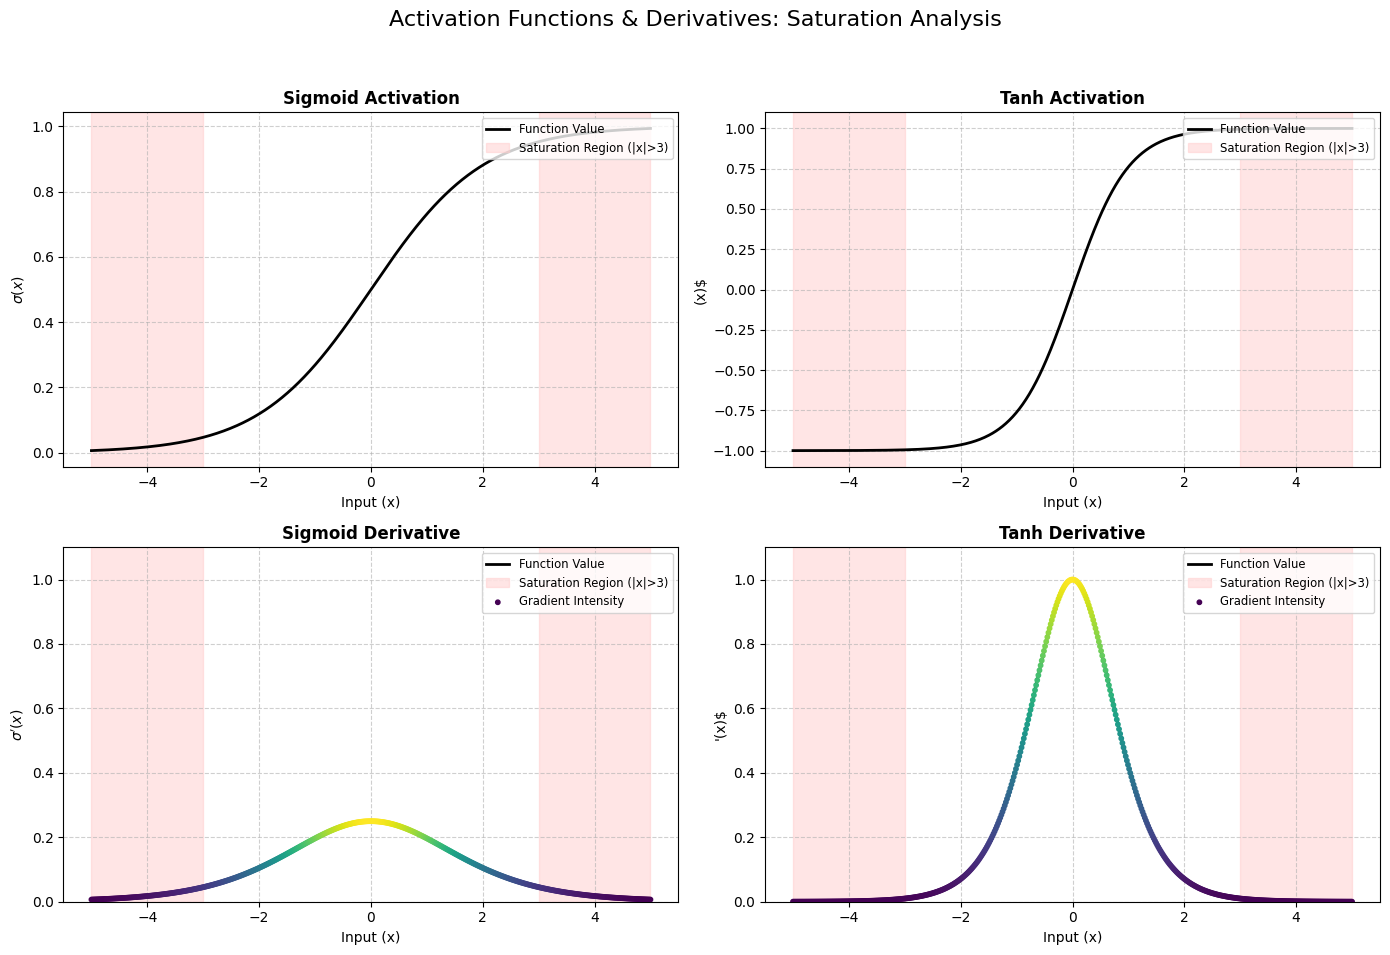

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    t = tanh(x)
    return 1 - t**2

def plot_activation_analysis():
    # 1. Setup Data
    x = np.linspace(-5, 5, 500)
    
    # Calculate values
    y_sig = sigmoid(x)
    dy_sig = sigmoid_derivative(x)
    y_tanh = tanh(x)
    dy_tanh = tanh_derivative(x)

    # 2. Create 2x2 Subplot
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Activation Functions & Derivatives: Saturation Analysis', fontsize=16)

    # Helper function to style plots and mark saturation
    def style_plot(ax, x_data, y_data, title, ylabel, is_derivative=False):
        # Plot the main line
        ax.plot(x_data, y_data, color='black', linewidth=2, label='Function Value')
        
        # Mark Saturation Regions (|x| > 3)
        # We shade the background red where the neuron is saturated
        saturation_color = '#ffcccc' # Light red
        ax.axvspan(-5, -3, color=saturation_color, alpha=0.5, label='Saturation Region (|x|>3)')
        ax.axvspan(3, 5, color=saturation_color, alpha=0.5)
        
        # If it's a derivative, add a "heatmap" effect to show gradient flow intensity
        if is_derivative:
            # Scatter plot with colormap to visualize "heat" (magnitude of gradient)
            # High gradient = Green/Yellow, Low gradient (vanishing) = Dark/Black
            ax.scatter(x_data, y_data, c=y_data, cmap='viridis', s=10, zorder=3, label='Gradient Intensity')
            ax.set_ylim(0, 1.1) # Derivatives of these functions are between 0 and 1
        
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_ylabel(ylabel)
        ax.set_xlabel('Input (x)')
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(loc='upper right', fontsize='small')

    # --- Top Row: Activations ---
    style_plot(axs[0, 0], x, y_sig, 'Sigmoid Activation', '$\sigma(x)$')
    style_plot(axs[0, 1], x, y_tanh, 'Tanh Activation', '(x)$')

    # --- Bottom Row: Derivatives ---
    style_plot(axs[1, 0], x, dy_sig, 'Sigmoid Derivative', '$\sigma\'(x)$', is_derivative=True)
    style_plot(axs[1, 1], x, dy_tanh, 'Tanh Derivative', '\'(x)$', is_derivative=True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
    plt.show()

if __name__ == "__main__":
    plot_activation_analysis()


Dead ReLUs: Sample a linear layer z = Wx+b with poor bias (b << 0). Show fraction of activations that are zero for ReLU vs LeakyReLU; discuss optimization impact.

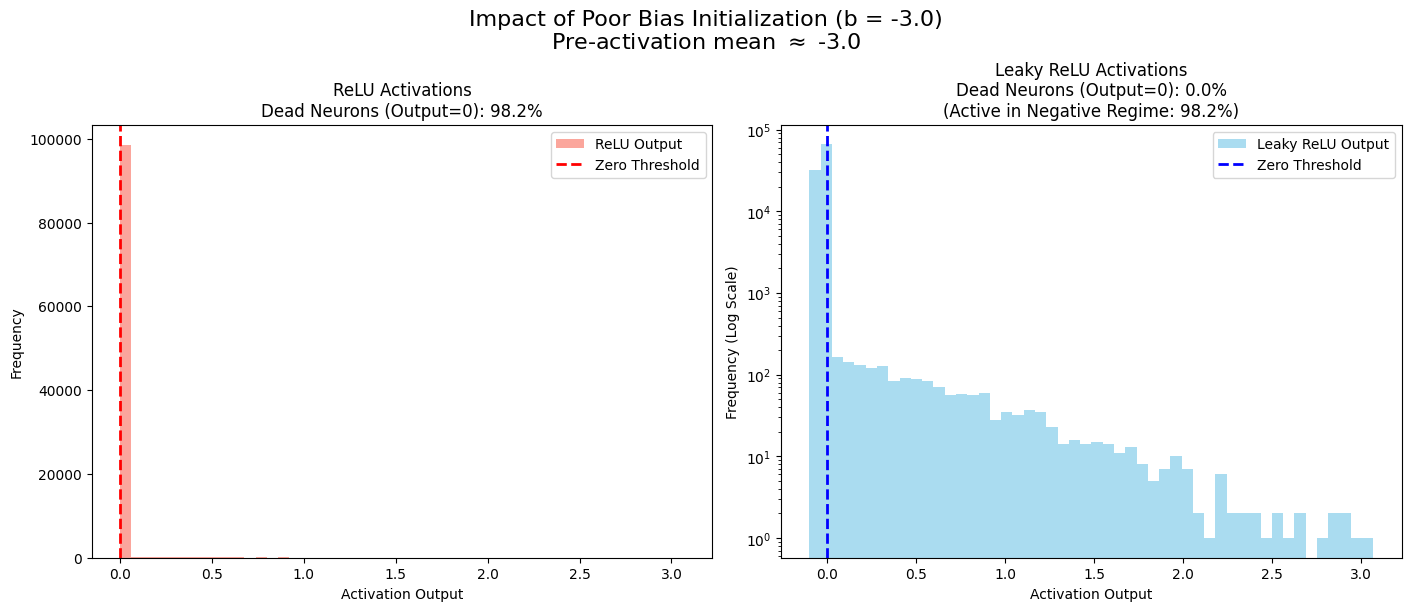

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_dead_neurons():
    # 1. Setup Simulation Parameters
    np.random.seed(42)
    n_samples = 1000
    n_input = 50
    n_neurons = 100
    
    # 2. Generate Data and Weights
    X = np.random.randn(n_samples, n_input)
    W = np.random.randn(n_input, n_neurons) * np.sqrt(2 / n_input)
    b = np.full((n_neurons,), -3.0) 
    
    # 3. Linear Pass (z = Wx + b)
    z = np.dot(X, W) + b
    
    # 4. Apply Activations
    activations_relu = np.maximum(0, z)
    
    alpha = 0.01
    activations_leaky = np.where(z > 0, z, z * alpha)
    
    # 5. Calculate Statistics
    total_activations = z.size
    frac_zero_relu = np.sum(activations_relu == 0) / total_activations
    frac_zero_leaky = np.sum(activations_leaky == 0) / total_activations
    frac_neg_regime = np.sum(z <= 0) / total_activations

    # 6. Visualization
    # FIX: Use layout='constrained' instead of calling tight_layout manually.
    # This automatically reserves space for suptitle and prevents the ValueError.
    fig, axs = plt.subplots(1, 2, figsize=(14, 6), layout='constrained')
    
    fig.suptitle(f'Impact of Poor Bias Initialization (b = -3.0)\nPre-activation mean $\\approx$ -3.0', fontsize=16)
    
    # Plot 1: ReLU Histogram
    axs[0].hist(activations_relu.flatten(), bins=50, color='salmon', alpha=0.7, label='ReLU Output')
    axs[0].set_title(f'ReLU Activations\nDead Neurons (Output=0): {frac_zero_relu:.1%}')
    axs[0].set_xlabel('Activation Output')
    axs[0].set_ylabel('Frequency')
    axs[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Threshold')
    axs[0].legend()
    
    # Plot 2: Leaky ReLU Histogram
    axs[1].hist(activations_leaky.flatten(), bins=50, color='skyblue', alpha=0.7, label='Leaky ReLU Output')
    axs[1].set_title(f'Leaky ReLU Activations\nDead Neurons (Output=0): {frac_zero_leaky:.1%}\n(Active in Negative Regime: {frac_neg_regime:.1%})')
    axs[1].set_xlabel('Activation Output')
    axs[1].set_yscale('log') 
    axs[1].set_ylabel('Frequency (Log Scale)')
    axs[1].axvline(0, color='blue', linestyle='--', linewidth=2, label='Zero Threshold')
    axs[1].legend()
    
    # REMOVED: plt.tight_layout(rect=[...]) 
    # The layout='constrained' in subplots handles this automatically now.
    plt.show()
    
    return frac_zero_relu, frac_zero_leaky

if __name__ == "__main__":
    simulate_dead_neurons()


Initialization sweep: For a 3‑layer MLP, vary weight scale and compare gradient norms across layers for sigmoid vs ReLU. Plot exploding/vanishing behavior.

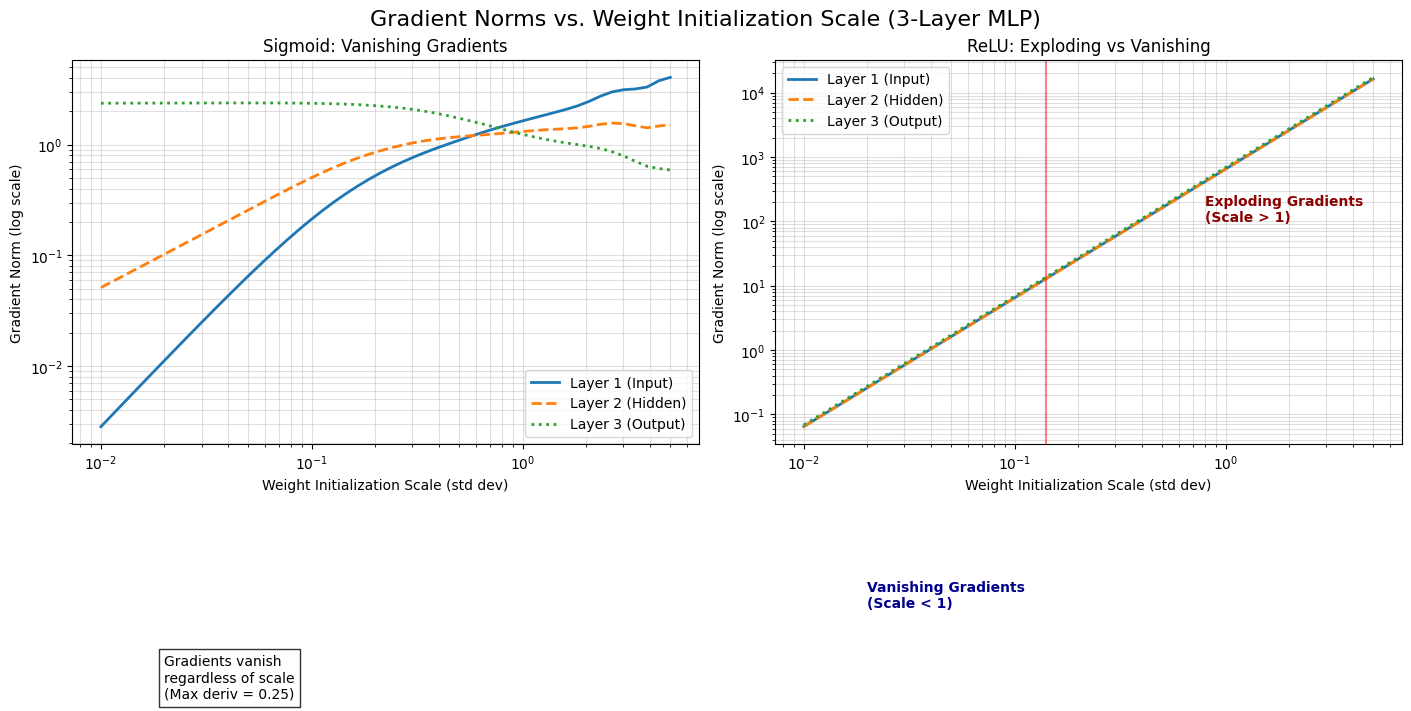

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def d_sigmoid(x):
    s = sigmoid(x)
    return s * (1 - s)

def relu(x):
    return np.maximum(0, x)

def d_relu(x):
    return (x > 0).astype(float)

def get_layer_gradients(scale, act_fn, d_act_fn, input_dim=100, hidden_dim=100):
    """
    Simulates a forward and backward pass for a 3-layer MLP.
    Returns the Frobenius norm of the gradients for each layer.
    """
    np.random.seed(42) # Fixed seed for consistency across scales
    batch_size = 32
    
    # 1. Initialize Weights
    # W1, W2, W3 with shape (dim, dim)
    W1 = np.random.randn(input_dim, hidden_dim) * scale
    W2 = np.random.randn(hidden_dim, hidden_dim) * scale
    W3 = np.random.randn(hidden_dim, hidden_dim) * scale
    
    # Input Data
    X = np.random.randn(batch_size, input_dim)
    
    # 2. Forward Pass
    z1 = X @ W1
    a1 = act_fn(z1)
    
    z2 = a1 @ W2
    a2 = act_fn(z2)
    
    z3 = a2 @ W3
    a3 = act_fn(z3)
    
    # 3. Backward Pass
    # Assume a dummy loss gradient at the output (e.g., dL/da3 is random)
    # This simulates the incoming gradient from the loss function
    grad_output = np.random.randn(*a3.shape)
    
    # Layer 3 Gradients
    delta3 = grad_output * d_act_fn(z3)
    dW3 = a2.T @ delta3
    
    # Layer 2 Gradients
    delta2 = (delta3 @ W3.T) * d_act_fn(z2)
    dW2 = a1.T @ delta2
    
    # Layer 1 Gradients
    delta1 = (delta2 @ W2.T) * d_act_fn(z1)
    dW1 = X.T @ delta1
    
    # Return norms normalized by batch size
    return [
        np.linalg.norm(dW1) / batch_size,
        np.linalg.norm(dW2) / batch_size,
        np.linalg.norm(dW3) / batch_size
    ]

def run_sweep():
    # Scales to sweep: 0.01 to 5.0 (Logarithmic spacing)
    scales = np.logspace(-2, 0.7, 50)
    
    # Store results
    results_sig = {1: [], 2: [], 3: []}
    results_relu = {1: [], 2: [], 3: []}
    
    for s in scales:
        # Sigmoid Sweep
        g_sig = get_layer_gradients(s, sigmoid, d_sigmoid)
        results_sig[1].append(g_sig[0])
        results_sig[2].append(g_sig[1])
        results_sig[3].append(g_sig[2])
        
        # ReLU Sweep
        g_relu = get_layer_gradients(s, relu, d_relu)
        results_relu[1].append(g_relu[0])
        results_relu[2].append(g_relu[1])
        results_relu[3].append(g_relu[2])

    # Plotting
    fig, axs = plt.subplots(1, 2, figsize=(14, 6), layout='constrained')
    fig.suptitle('Gradient Norms vs. Weight Initialization Scale (3-Layer MLP)', fontsize=16)
    
    def plot_results(ax, results, title):
        ax.plot(scales, results[1], label='Layer 1 (Input)', linewidth=2)
        ax.plot(scales, results[2], label='Layer 2 (Hidden)', linewidth=2, linestyle='--')
        ax.plot(scales, results[3], label='Layer 3 (Output)', linewidth=2, linestyle=':')
        
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('Weight Initialization Scale (std dev)')
        ax.set_ylabel('Gradient Norm (log scale)')
        ax.set_title(title)
        ax.grid(True, which="both", ls="-", alpha=0.4)
        ax.legend()

    # Sigmoid Plot
    plot_results(axs[0], results_sig, 'Sigmoid: Vanishing Gradients')
    # Add annotation for Sigmoid
    axs[0].text(0.02, 1e-5, 'Gradients vanish\nregardless of scale\n(Max deriv = 0.25)', 
                fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

    # ReLU Plot
    plot_results(axs[1], results_relu, 'ReLU: Exploding vs Vanishing')
    # Add annotation for ReLU
    axs[1].axvline(np.sqrt(2/100), color='red', linestyle='-', alpha=0.5, label='He Init (approx)')
    axs[1].text(0.8, 1e2, 'Exploding Gradients\n(Scale > 1)', color='darkred', fontweight='bold')
    axs[1].text(0.02, 1e-4, 'Vanishing Gradients\n(Scale < 1)', color='darkblue', fontweight='bold')

    plt.show()

if __name__ == "__main__":
    run_sweep()


Swish x*sigmoid(x) and GELU (approx 0.5x(1+tanh(√(2/π)(x+0.044715x^3))))—add them to the plots and discuss why they can outperform ReLU.

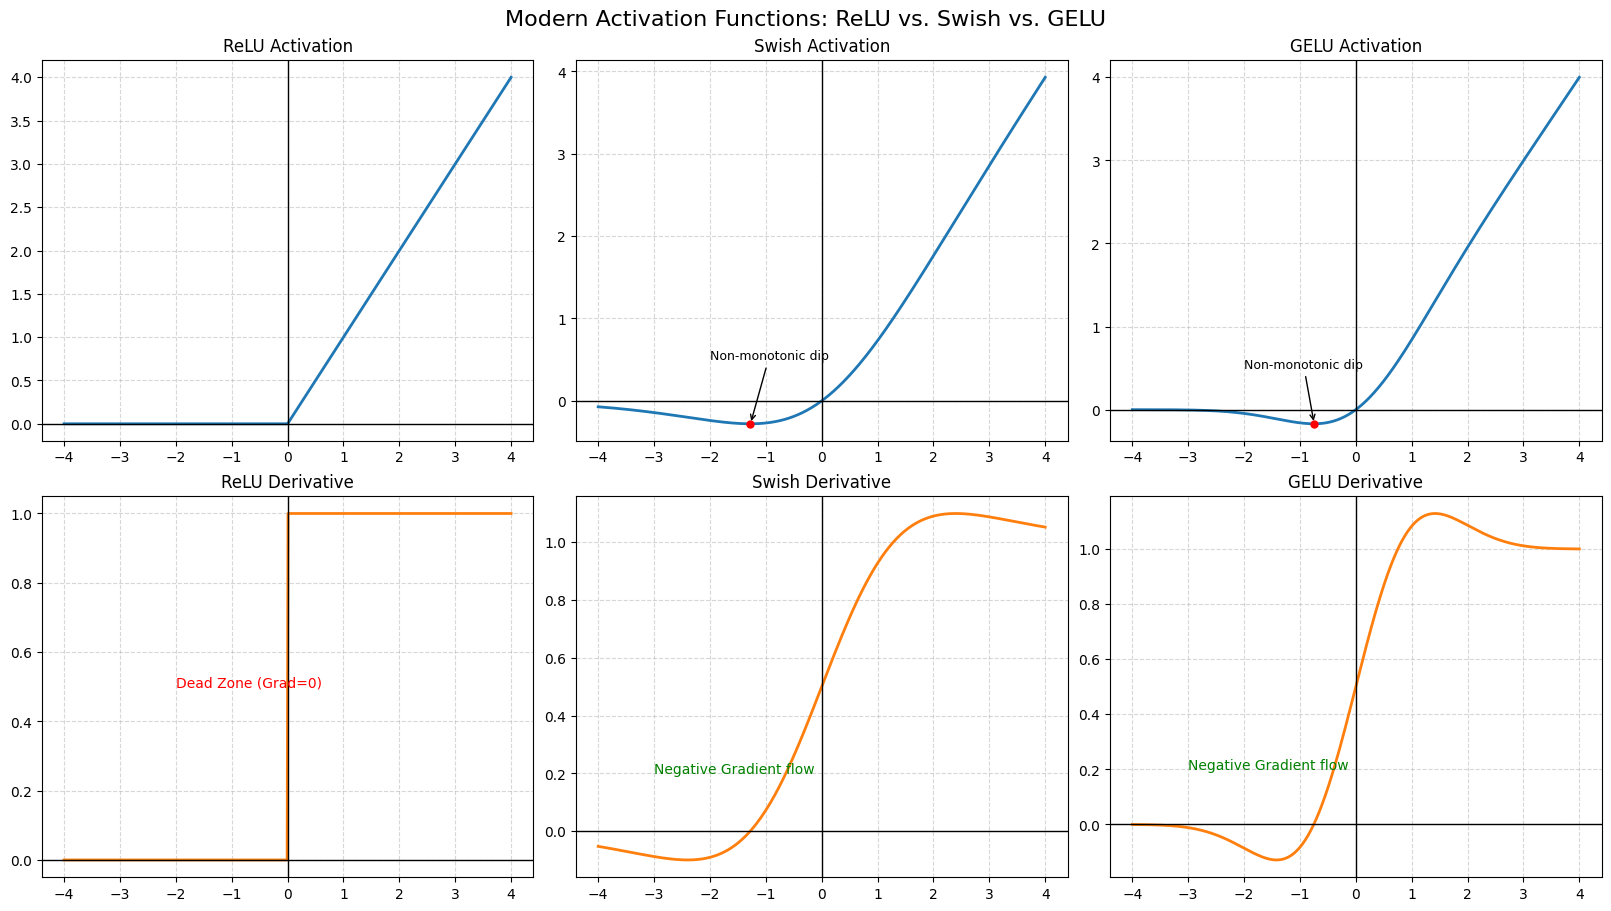

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# --- ReLU ---
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

# --- Swish (SiLU) ---
# f(x) = x * sigmoid(x)
def swish(x):
    return x * sigmoid(x)

def swish_derivative(x):
    s = sigmoid(x)
    f_x = swish(x)
    # Derivative: f(x) + sigmoid(x)(1 - f(x)) is a common approximation form,
    # but exact product rule is: 1*s + x*s*(1-s) = s + f_x - f_x*s
    return s + f_x * (1 - s)

# --- GELU (Approximation) ---
# f(x) approx 0.5x(1 + tanh(sqrt(2/pi)(x + 0.044715x^3)))
def gelu(x):
    c1 = np.sqrt(2 / np.pi)
    c2 = 0.044715
    inner = c1 * (x + c2 * x**3)
    return 0.5 * x * (1 + np.tanh(inner))

def gelu_derivative(x):
    # Analytical derivative of the approximation
    c1 = np.sqrt(2 / np.pi)
    c2 = 0.044715
    
    inner = c1 * (x + c2 * x**3)
    tanh_inner = np.tanh(inner)
    sech_sq = 1 - tanh_inner**2
    
    du_dx = c1 * (1 + 3 * c2 * x**2)
    
    # Product rule: 0.5 * [1*(1+tanh) + x * sech^2 * du_dx]
    return 0.5 * (1 + tanh_inner) + 0.5 * x * sech_sq * du_dx

def plot_modern_activations():
    x = np.linspace(-4, 4, 500)
    
    # Data preparation
    funcs = [
        ('ReLU', relu(x), relu_derivative(x)),
        ('Swish', swish(x), swish_derivative(x)),
        ('GELU', gelu(x), gelu_derivative(x))
    ]
    
    fig, axs = plt.subplots(2, 3, figsize=(16, 9), layout='constrained')
    fig.suptitle('Modern Activation Functions: ReLU vs. Swish vs. GELU', fontsize=16)
    
    for i, (name, y, dy) in enumerate(funcs):
        # --- Top Row: Activations ---
        ax_act = axs[0, i]
        ax_act.plot(x, y, linewidth=2, color='tab:blue', label=f'{name}(x)')
        ax_act.set_title(f'{name} Activation')
        ax_act.grid(True, linestyle='--', alpha=0.5)
        ax_act.axhline(0, color='black', linewidth=1)
        ax_act.axvline(0, color='black', linewidth=1)
        
        # Highlight the "dip" in negative region for Swish/GELU
        if name in ['Swish', 'GELU']:
            min_y = np.min(y)
            min_x = x[np.argmin(y)]
            ax_act.plot(min_x, min_y, 'ro', markersize=5)
            ax_act.annotate('Non-monotonic dip', xy=(min_x, min_y), xytext=(-2, 0.5),
                            arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=9)

        # --- Bottom Row: Derivatives ---
        ax_der = axs[1, i]
        ax_der.plot(x, dy, linewidth=2, color='tab:orange', label=f'{name}\'(x)')
        ax_der.set_title(f'{name} Derivative')
        ax_der.grid(True, linestyle='--', alpha=0.5)
        ax_der.axhline(0, color='black', linewidth=1)
        ax_der.axvline(0, color='black', linewidth=1)
        
        # Highlight derivative behavior near 0
        if name == 'ReLU':
            ax_der.text(-2, 0.5, 'Dead Zone (Grad=0)', color='red')
        else:
            ax_der.text(-3, 0.2, 'Negative Gradient flow', color='green')

    plt.show()

if __name__ == "__main__":
    plot_modern_activations()
